In [12]:
import pandas as pd 
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [14]:
os.makedirs("Read_age_DEG_df/", exist_ok=True)

In [2]:
age_res_df = pd.read_csv('Read_Supplemental_Data_11_age.csv', index_col = 0)
age_res_df.head()

# use threshold of q<0.05
age_res_df = age_res_df[age_res_df['q_val'] < 0.05]

In [3]:
Counter(age_res_df.cellType)

Counter({'Ventricular_Cardiomyocytes': 703,
         'Fibroblast': 28,
         'Neuron': 24,
         'Adipocytes': 15,
         'Lymphocyte': 3,
         'Endothelium': 2,
         'Perivascular': 1})

In [4]:
# create consistent cell type

age_res_df['consistent_cell_type'] = age_res_df['cellType'].map(
    {"Ventricular_Cardiomyocytes": "Cardiomyocyte",
    "Endothelium": "Endothelial",
     "Adipocytes": "Adipocyte",
     "Myeloid": "Myeloid",
    "Lymphocyte": "Lymphoid",
    "Lymphatic_Endothelium": "LEC",
    "Neuron": "Neuronal",
    "Mast_Cell": "Mast",
    "Perivascular": "Pericyte",
    "Fibroblast": "Fibroblast"}
)

In [5]:
Counter(age_res_df.consistent_cell_type) 

Counter({'Cardiomyocyte': 703,
         'Fibroblast': 28,
         'Neuronal': 24,
         'Adipocyte': 15,
         'Lymphoid': 3,
         'Endothelial': 2,
         'Pericyte': 1})

In [6]:
age_res_df.sort_values(by = "consistent_cell_type")

,gene,coefficientValue,q_val,pval,cellType,Effect_Magnitude,Effect_Direction,consistent_cell_type
69083,COP1,-0.007365,0.009601,8.168654e-06,Adipocytes,0.007365,Negative,Adipocyte
67494,PDLIM3,0.047694,0.036097,6.142400e-05,Adipocytes,0.047694,Positive,Adipocyte
67495,AC002316.1,0.046212,0.014149,1.805704e-05,Adipocytes,0.046212,Positive,Adipocyte
67501,GLDN,-0.038601,0.006939,9.839545e-07,Adipocytes,0.038601,Negative,Adipocyte
67503,JUN,0.038287,0.049231,1.047172e-04,Adipocytes,0.038287,Positive,Adipocyte
...,...,...,...,...,...,...,...,...
62420,ZNF532,0.010601,0.039726,7.762645e-05,Neuron,0.010601,Positive,Neuronal
62372,PALLD,-0.011824,0.042442,1.284761e-04,Neuron,0.011824,Negative,Neuronal
63847,CHD9,-0.004343,0.042442,1.320253e-04,Neuron,0.004343,Negative,Neuronal
62325,RAI14,-0.014220,0.049759,2.057228e-04,Neuron,0.014220,Negative,Neuronal


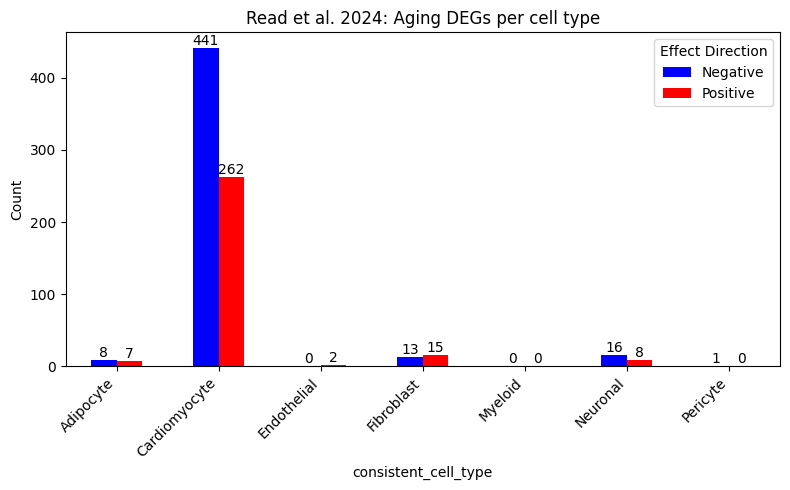

In [7]:
# get counts of DEGs
counts = age_res_df.groupby(["consistent_cell_type", "Effect_Direction"]).size().reset_index(name="count")

# change order for x-axis
custom_order = ["Adipocyte", "Cardiomyocyte", "Endothelial", "Fibroblast", "Myeloid", "Neuronal", "Pericyte"]
counts["consistent_cell_type"] = pd.Categorical(
    counts["consistent_cell_type"],
    categories=custom_order,
    ordered=True
)

# pivot long
pivot_counts = counts.pivot(index="consistent_cell_type", columns="Effect_Direction", values="count").fillna(0)
pivot_counts = pivot_counts.reindex(custom_order)

# make barplot
ax = pivot_counts.plot(
    kind="bar",
    figsize=(8,5),
    color={"Positive": "red", "Negative": "blue"}
)

for container in ax.containers:
    ax.bar_label(container, label_type="edge")

plt.ylabel("Count")
plt.title("Read et al. 2024: Aging DEGs per cell type")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Effect Direction")
plt.tight_layout()
plt.show()

In [9]:
unique_cell_types = age_res_df.consistent_cell_type.unique()
unique_cell_types

array(['Endothelial', 'Fibroblast', 'Lymphoid', 'Pericyte',
       'Cardiomyocyte', 'Neuronal', 'Adipocyte'], dtype=object)

In [16]:
for cell_type in unique_cell_types:
    cell_type_res_df = age_res_df[age_res_df['consistent_cell_type'] == cell_type]
    cell_type_res_df.to_csv("Read_age_DEG_df/" + cell_type + "_DEG.csv")
    print(cell_type)

Endothelial
Fibroblast
Lymphoid
Pericyte
Cardiomyocyte
Neuronal
Adipocyte
